# <font size = 10 color = brown><b> Unsupervised - Clustering

In [1]:
# basic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# for plotting
import plotly.express as px

# for k means clustering
from sklearn.cluster import KMeans

# for standardization
from sklearn.preprocessing  import StandardScaler

# for evaluation
from sklearn.metrics import silhouette_score

## <font size = 6 color = seagreen><b> Get data 

In [2]:
data = pd.read_csv('~/OneDrive/Emeritus/IITG-DSBA March 27th/Predictive/final datasets/Clustering_data.csv', index_col = 0)
data.head(3)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6


In [3]:
data.columns = ['Gender', 'Age', 'AnnualIncome', 'SpendingScore']

## <font size = 6 color = seagreen><b>Filter for numerical columns

In [11]:
import warnings
warnings.filterwarnings('ignore')

In [12]:
new_data = data[['AnnualIncome', 'SpendingScore']]

## <font size = 6 color = seagreen><b>Visualize the distribution

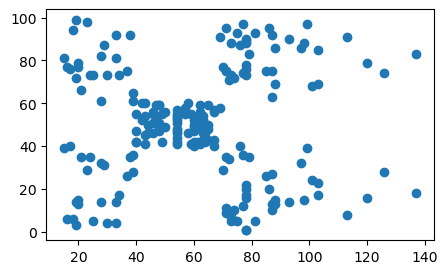

In [13]:
plt.figure(figsize = (5,3))
plt.scatter(new_data['AnnualIncome'], new_data['SpendingScore'])
plt.show()

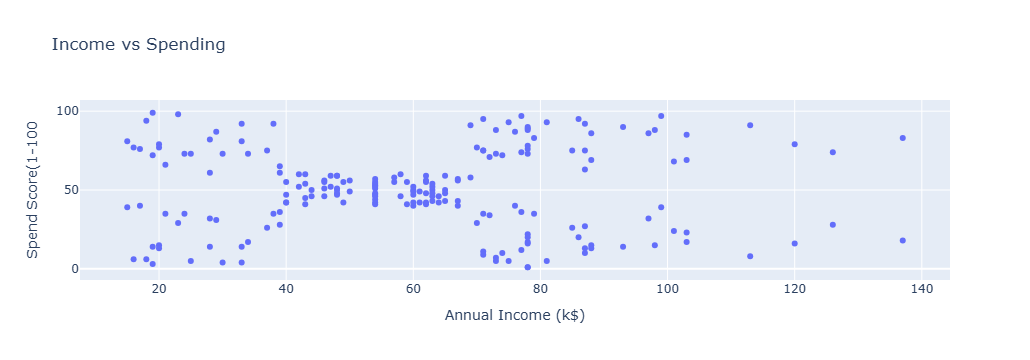

In [14]:
fig = px.scatter(new_data, x = 'AnnualIncome', y = 'SpendingScore', title = 'Income vs Spending',
          labels = {'AnnualIncome':'Annual Income (k$)', 'SpendingScore': 'Spend Score(1-100' })
fig.show()

## <font size = 6 color = seagreen><b>Standardize the data

In [15]:
sc = StandardScaler()
std_data = sc.fit_transform(new_data)

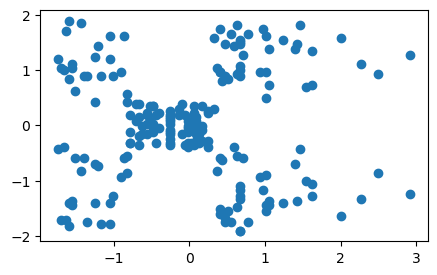

In [16]:
plt.figure(figsize = (5,3))
plt.scatter(std_data[:,0], std_data[:, 1])
plt.show()

## <font size = 6 color = seagreen><b>optimal $k$

- the range of k is min 1 to a max
- generally 20 to 25 clusters should be enogh for a very large dataset
- max(# of rows, 25)

### <font size = 5 color = steelblue><b> In any clustering :

<font size = 4 color = gray>
    
1. the homogeneity within the cluster should be maximum | deviation within cluster to be minimum
2. the heterogeneity between clusters should be maximum | 2 clusters should be well separated | devaition between clusters should be maximum

In [30]:
max_rows = new_data.shape[0]
max_clusters = min(max_rows, 25)

wss_k = {}
for k in range(1, max_clusters):
    
    # defining the kmeans object with the no. of clusters
    kmeans = KMeans(n_clusters= k, max_iter=500,)

    # training with the data 
    kmeans.fit(std_data)

    # within sum of squares deviation(error)
    wss_k[k] = kmeans.inertia_


In [31]:
elbow_data = pd.Series(wss_k)
elbow_data.tail(2)

23    10.625498
24     9.931023
dtype: float64

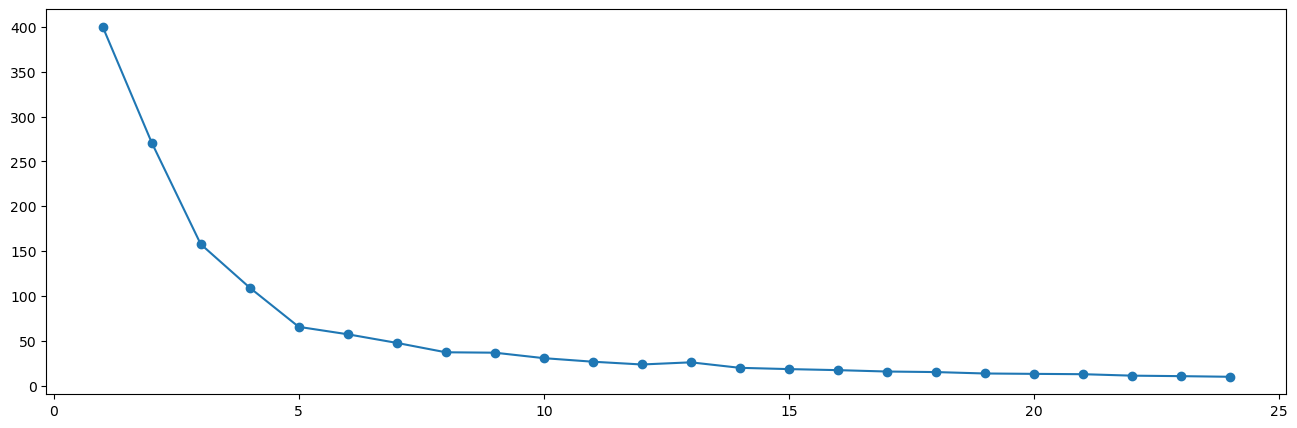

In [32]:
plt.figure(figsize = (16, 5))
plt.plot(elbow_data, marker = "o")
plt.show()

---

<center> <font size = 5 color = steelblue><b> elbow point : point of sharp change
 
---

## <font size = 6 color = seagreen><b>Create Clusters using optimal $k$

In [24]:
kmeans = KMeans(n_clusters= 5, max_iter= 500)
kmeans.fit(std_data)

KMeans(max_iter=500, n_clusters=5)

## <font size = 6 color = seagreen><b>Get Cluster Labels

In [26]:
clus_labs = kmeans.predict(std_data)

In [28]:
labelled_data = new_data.assign(Cluster_label = clus_labs)
labelled_data.head(2)

,AnnualIncome,SpendingScore,Cluster_label
CustomerID,,,
1,15,39,3
2,15,81,4


## <font size = 6 color = seagreen><b>Get Cluster Profiles

In [38]:
clusterProfile = labelled_data.groupby(['Cluster_label']).agg({'Cluster_label':len,'AnnualIncome':'mean', 'SpendingScore': 'median'})

In [39]:
clusterProfile

,Cluster_label,AnnualIncome,SpendingScore
Cluster_label,,,
0,36,87.750000,16.0
1,39,86.538462,83.0
2,80,55.087500,50.0
3,23,26.304348,17.0
4,22,25.727273,77.0


## <font size = 6 color = seagreen><b>Visualize the newly formed clusters 

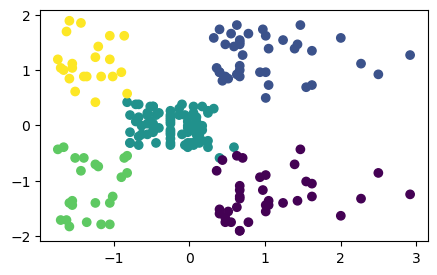

In [41]:
plt.figure(figsize = (5,3))
plt.scatter(std_data[:,0], std_data[:, 1], c = clus_labs)
plt.show()

In [42]:
import seaborn as sns

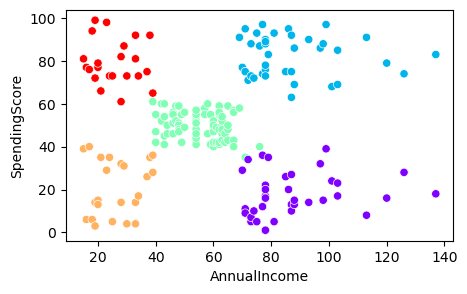

In [50]:
plt.figure(figsize = (5, 3))
sns.scatterplot(data = labelled_data, x = 'AnnualIncome', y = 'SpendingScore', hue = 'Cluster_label', palette= 'rainbow', legend = False)
plt.show()

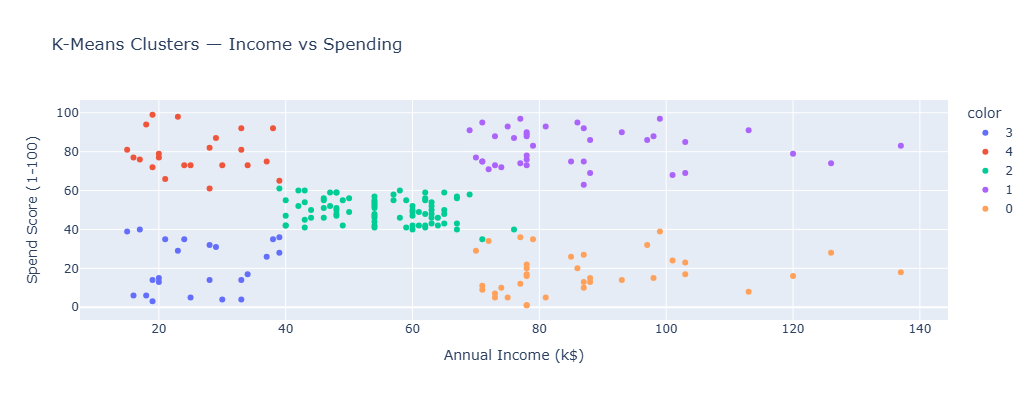

In [54]:
fig = px.scatter(
    labelled_data,
    x='AnnualIncome',
    y='SpendingScore',
    color=labelled_data['Cluster_label'].astype(str),   # convert to string for categorical colors
    title='K-Means Clusters — Income vs Spending',
    labels={'AnnualIncome':'Annual Income (k$)', 'SpendingScore':'Spend Score (1-100)'},
    width=800,
    height=400,
    hover_data=['AnnualIncome','SpendingScore']
)
fig.show()

## <font size = 6 color = seagreen><b> Evaluation of K Means: Silhouette Score

In [56]:
print(f'Silhoutte Score for the KMeans clustering (k = 5): {silhouette_score(std_data, clus_labs):.3f}')

Silhoutte Score for the KMeans clustering (k = 5): 0.554


In [58]:
kmeans_7 = KMeans(n_clusters= 7, max_iter= 500)
kmeans_7.fit(std_data)
clus_labs_7 = kmeans_7.predict(std_data)
print(f'Silhoutte Score for the KMeans clustering(k = 7): {silhouette_score(std_data, clus_labs_7):.3f}')

Silhoutte Score for the KMeans clustering(k = 7): 0.457


In [59]:
kmeans_3 = KMeans(n_clusters= 3, max_iter= 500)
kmeans_3.fit(std_data)
clus_labs_3 = kmeans_3.predict(std_data)
print(f'Silhoutte Score for the KMeans clustering(k = 3): {silhouette_score(std_data, clus_labs_3):.3f}')

Silhoutte Score for the KMeans clustering(k = 3): 0.467


In [63]:
max_rows = new_data.shape[0]
max_clusters = min(max_rows, 25)

sil_score = {}
for k in range(2, max_clusters):
    
    # defining the kmeans object with the no. of clusters
    kmeans = KMeans(n_clusters= k, max_iter=500,)

    # training with the data 
    kmeans.fit(std_data)

    # silhoutte score
    clus_labs = kmeans.predict(std_data)
    sil_score[k] = silhouette_score(std_data, clus_labs)
sil_score_data = pd.Series(sil_score)

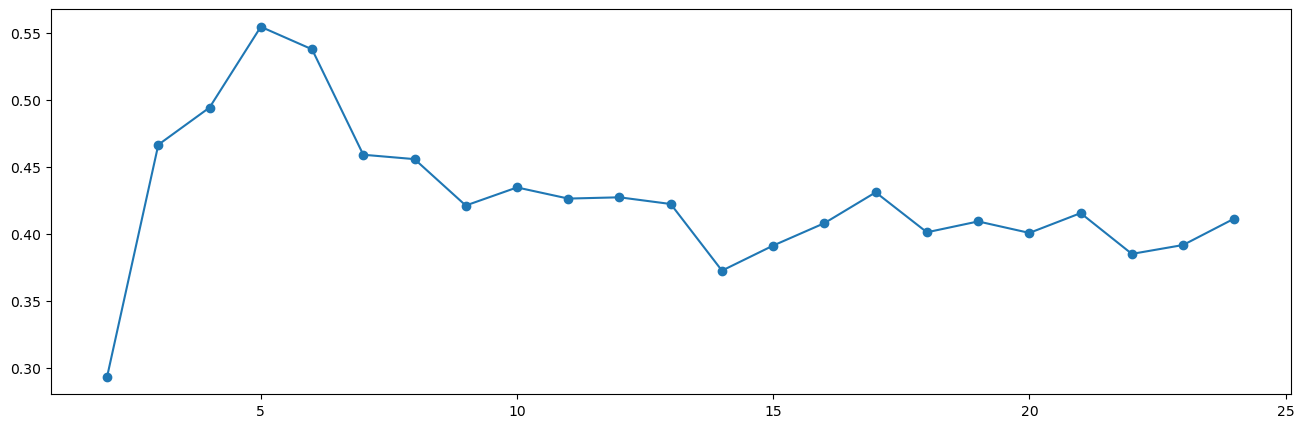

In [64]:
plt.figure(figsize = (16, 5))
plt.plot(sil_score_data, marker = "o")
plt.show()